# Homework: Inverted Pendulum World Model Training

This notebook runs the official homework workflow: install dependencies, generate MuJoCo ground-truth windows, train the starter world model, evaluate locked nMSE/VPT scoreboard metrics, and plot diagnostics.

The assignment trains **one dynamics world model**. It does not train a policy, does not use reward, and does not use actor-critic updates.

The public scoreboard is for debugging and comparison. Official grading uses TA-private data generated with hidden seeds.

## 1. Configure Repository

If you are running this notebook inside a local clone, the setup cell will reuse the current repository. Otherwise, set `COURSE_REPO_URL` to your fork and the notebook will clone it.

In [4]:
from pathlib import Path
import os
import subprocess
import sys

COURSE_REPO_URL = "https://github.com/aooooofu-code/EEC289A_WorldModel-Homework.git"
COURSE_REPO_BRANCH = "main"
SMOKE_RUN = False  # Full public profile by default.
RUN_SCOREBOARD_DEMO = True  # Generate/evaluate configs/public_scoreboard.yaml windows by default.

def run(cmd, cwd=None):
    cmd = [str(part) for part in cmd]
    print("+", " ".join(cmd))
    return subprocess.run(cmd, cwd=cwd, check=True)

def find_existing_repo(start: Path):
    for path in [start, *start.parents]:
        if (path / "wm_hw").is_dir() and (path / "configs" / "dev.yaml").exists():
            return path
    return None

def default_clone_dir():
    content = Path("/content")
    if content.exists() and os.access(content, os.W_OK):
        return content / "wm_inverted_pendulum_hw"
    return Path.home() / "wm_inverted_pendulum_hw"

repo = find_existing_repo(Path.cwd())
if repo is None:
    repo = default_clone_dir()
    if not (repo / ".git").exists():
        run(["git", "clone", "--branch", COURSE_REPO_BRANCH, COURSE_REPO_URL, repo])
    else:
        print(f"Using existing repo at {repo}")

COURSE_REPO_DIR = repo.resolve()
print("COURSE_REPO_DIR =", COURSE_REPO_DIR)

+ git clone --branch main https://github.com/aooooofu-code/EEC289A_WorldModel-Homework.git /content/wm_inverted_pendulum_hw
COURSE_REPO_DIR = /content/wm_inverted_pendulum_hw


## 2. Install Dependencies And Verify MuJoCo

In [6]:
%cd {COURSE_REPO_DIR}
!{sys.executable} -m pip install -q -U pip wheel "setuptools<82"
!{sys.executable} -m pip install -q -r requirements.txt

import gymnasium as gym
import torch

env = gym.make("InvertedPendulum-v5", reset_noise_scale=0.01)
obs, info = env.reset(seed=0)
print("obs shape:", obs.shape)
print("action shape:", env.action_space.shape)
print("action range:", env.action_space.low, env.action_space.high)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
env.close()

/content/wm_inverted_pendulum_hw
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 58.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
obs shape: (4,)
action shape: (1,)
action range: [-3.] [3.]
torch: 2.10.0+cpu
cuda available: False


## 3. Run Tests

These tests check the environment, dataset schema, no-leak open-loop rollout, differentiable loss, locked VPT/nMSE metrics, and train/eval smoke path.

In [7]:
!{sys.executable} -m pytest -q -m "not slow"

.............                                                            [100%]
13 passed, 1 deselected in 7.43s


## 4. Generate MuJoCo Ground-Truth Windows

In [8]:
DATASET_DIR = "data/dev_smoke" if SMOKE_RUN else "data/dev"
smoke_flag = "--smoke" if SMOKE_RUN else ""
!{sys.executable} -m wm_hw.dataset --config configs/dev.yaml --output-dir {DATASET_DIR} {smoke_flag}

{
  "output_dir": "data/dev",
  "written": {
    "train": "data/dev/train.npz",
    "val": "data/dev/val.npz",
    "test": "data/dev/test.npz",
    "ood": "data/dev/ood.npz"
  },
  "metadata": {
    "env_id": "InvertedPendulum-v5",
    "seed": 289,
    "smoke": false,
    "warmup_steps": 10,
    "max_horizon": 100,
    "window_states": 111,
    "window_actions": 110,
    "action_range": [
      -3.0,
      3.0
    ],
    "splits": {
      "train": {
        "states": [
          4096,
          111,
          4
        ],
        "actions": [
          4096,
          110,
          1
        ]
      },
      "val": {
        "states": [
          512,
          111,
          4
        ],
        "actions": [
          512,
          110,
          1
        ]
      },
      "test": {
        "states": [
          512,
          111,
          4
        ],
        "actions": [
          512,
          110,
          1
        ]
      },
      "ood": {
        "states": [
          512

In [1]:
%cd /content/wm_inverted_pendulum_hw

[Errno 2] No such file or directory: '/content/wm_inverted_pendulum_hw'
/content


In [2]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [ ]:
!git add .

In [11]:
!git config --global user.email "aofu@ucdavis.edu"
!git config --global user.name "Ao"

In [ ]:
!git commit -m "best 28 score config"

[main 6acc8f5] best 28 score config
 3 files changed, 86 insertions(+), 22 deletions(-)


In [ ]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [9]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [12]:
!git add notebooks/homework_colab.ipynb
!git commit -m "save notebook"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


## 5. Train The Starter World Model

In [ ]:
!{sys.executable} -m wm_hw.train --config configs/student.yaml --model student --dataset-dir {DATASET_DIR} --output-dir artifacts/student {smoke_flag}

[train] model=student device=cuda updates=3000 smoke=False
[train] update=1 loss/total=1.3270 loss/one_step=0.9859 loss/rollout=1.1659 max_horizon=100.0000 nMSE_AUC=1.1707 nMSE@1=0.2232 step_nMSE@1=0.2232 nMSE@5=0.5433 step_nMSE@5=0.8102 nMSE@10=0.7145 step_nMSE@10=0.9586 nMSE@90=1.6158 step_nMSE@90=2.7119 nMSE@100=1.7285 step_nMSE@100=2.9448 VPT80@0.10=0.0000 VPT50@0.10=0.0000 VPT80@0.25=0.0000 VPT50@0.25=1.0000 VPT80@0.50=1.0000 VPT50@0.50=3.0000 warmup_steps=10.0000 one_step_rmse=0.0730 open_loop_rmse@horizon=0.2085
[train] update=100 loss/total=0.2288 loss/one_step=0.1195 loss/rollout=0.2263 max_horizon=100.0000 nMSE_AUC=0.4053 nMSE@1=0.0288 step_nMSE@1=0.0288 nMSE@5=0.0844 step_nMSE@5=0.1358 nMSE@10=0.1417 step_nMSE@10=0.2433 nMSE@90=0.7452 step_nMSE@90=2.2395 nMSE@100=0.9642 step_nMSE@100=3.8752 VPT80@0.10=2.0000 VPT50@0.10=4.0000 VPT80@0.25=4.0000 VPT50@0.25=10.0000 VPT80@0.50=8.0000 VPT50@0.50=22.0000 warmup_steps=10.0000 one_step_rmse=0.0212 open_loop_rmse@horizon=0.1537
[trai

In [ ]:
!git config --global user.email "aofu@ucdavis.edu"
!git config --global user.name "Ao"

In [ ]:
!git add .
!git commit -m "backup best model"

[main 8d5eed0] backup best model
 3 files changed, 85 insertions(+), 17 deletions(-)


In [ ]:
!git tag best28

fatal: tag 'best28' already exists


In [ ]:
!git tag

best28


In [ ]:
def log_experiment(name, notes, metrics, config):
    print("=" * 60)
    print("EXPERIMENT:", name)
    print("=" * 60)
    print("Notes:")
    print(notes)

    print("\nMetrics:")
    for k, v in metrics.items():
        print(f"{k}: {v}")

    print("\nConfig:")
    for k, v in config.items():
        print(f"{k}: {v}")

In [ ]:
log_experiment(
    name="baseline_student_model",
    notes="Official starter baseline reproduced.",
    metrics={
        "VPT80@0.25": 22,
        "VPT50@0.25": 27,
        "nMSE@10": 0.0026,
        "nMSE@100": 1473.9,
        "one_step_rmse": 0.0068,
    },
    config={
        "hidden_dim": 128,
        "num_layers": 2,
        "use_gru": False,
        "batch_size": 128,
        "updates": 2000,
        "learning_rate": 1e-3,
        "rollout_weight": 1.2,
        "rollout_train_horizon": 20,
        "warmup_steps": 10,
        "max_horizon": 100,
    }
)

EXPERIMENT: baseline_student_model
Notes:
Official starter baseline reproduced.

Metrics:
VPT80@0.25: 22
VPT50@0.25: 27
nMSE@10: 0.0026
nMSE@100: 1473.9
one_step_rmse: 0.0068

Config:
hidden_dim: 128
num_layers: 2
use_gru: False
batch_size: 128
updates: 2000
learning_rate: 0.001
rollout_weight: 1.2
rollout_train_horizon: 20
warmup_steps: 10
max_horizon: 100


## 6. Evaluate Test And OOD VPT Scoreboard

In [ ]:
!{sys.executable} -m wm_hw.eval_horizon --checkpoint-dir artifacts/student/best_checkpoint --dataset-dir {DATASET_DIR} --split test --horizon auto --eval-config configs/official_eval.yaml --output-dir artifacts/student/eval_test
!{sys.executable} -m wm_hw.eval_horizon --checkpoint-dir artifacts/student/best_checkpoint --dataset-dir {DATASET_DIR} --split ood --horizon auto --eval-config configs/official_eval.yaml --output-dir artifacts/student/eval_ood

{
  "metrics_summary": {
    "max_horizon": 100,
    "VPT80@0.25": 22,
    "VPT50@0.25": 26,
    "nMSE_AUC": 234.02716064453125,
    "nMSE@10": 0.00417902460321784,
    "nMSE@90": 828.697021484375,
    "nMSE@100": 1292.4619140625,
    "step_nMSE@10": 0.007043896708637476,
    "step_nMSE@100": 6417.4423828125,
    "one_step_rmse": 0.006501621101051569,
    "open_loop_rmse@horizon": 5.459566593170166
  },
  "metrics_json": "artifacts/student/eval_test/metrics.json",
  "scoreboard_summary_json": "artifacts/student/eval_test/scoreboard_summary.json",
  "per_window_vpt_0p25": "artifacts/student/eval_test/per_window_vpt_0p25.npy"
}
{
  "metrics_summary": {
    "max_horizon": 100,
    "VPT80@0.25": 6,
    "VPT50@0.25": 13,
    "nMSE_AUC": 393.71417236328125,
    "nMSE@10": 0.12262813746929169,
    "nMSE@90": 1286.76708984375,
    "nMSE@100": 1871.240478515625,
    "step_nMSE@10": 0.2743834853172302,
    "step_nMSE@100": 8219.779296875,
    "one_step_rmse": 0.026473920792341232,
    "open_loop

In [ ]:
log_experiment(
    name="baseline_eval_test_ood",
    notes="Baseline model evaluated on test and OOD splits.",
    metrics={
        "test_VPT80@0.25": 22,
        "test_VPT50@0.25": 26,
        "test_nMSE@10": 0.00418,
        "test_nMSE@100": 1292.46,
        "test_one_step_rmse": 0.00650,
        "test_open_loop_rmse": 5.46,

        "ood_VPT80@0.25": 6,
        "ood_VPT50@0.25": 13,
        "ood_nMSE@10": 0.12263,
        "ood_nMSE@100": 1871.24,
        "ood_one_step_rmse": 0.02647,
        "ood_open_loop_rmse": 6.58,
    },
    config={
        "model": "baseline",
        "eval_horizon": 100,
        "warmup_steps": 10,
    }
)

EXPERIMENT: baseline_eval_test_ood
Notes:
Baseline model evaluated on test and OOD splits.

Metrics:
test_VPT80@0.25: 22
test_VPT50@0.25: 26
test_nMSE@10: 0.00418
test_nMSE@100: 1292.46
test_one_step_rmse: 0.0065
test_open_loop_rmse: 5.46
ood_VPT80@0.25: 6
ood_VPT50@0.25: 13
ood_nMSE@10: 0.12263
ood_nMSE@100: 1871.24
ood_one_step_rmse: 0.02647
ood_open_loop_rmse: 6.58

Config:
model: baseline
eval_horizon: 100
warmup_steps: 10


## 7. Plot Diagnostics

{'survival_curve': 'artifacts/student/plots/survival_curve.png', 'rollout_comparison': 'artifacts/student/plots/rollout_comparison.png'}
test VPT80@0.25: 22
ood VPT80@0.25: 6
test max_horizon: 100
test nMSE_AUC: 234.02716064453125


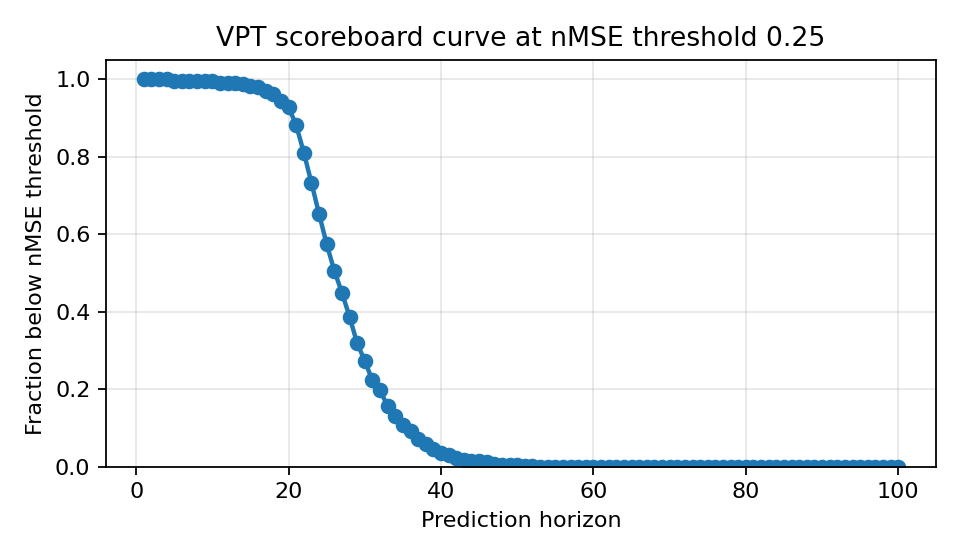

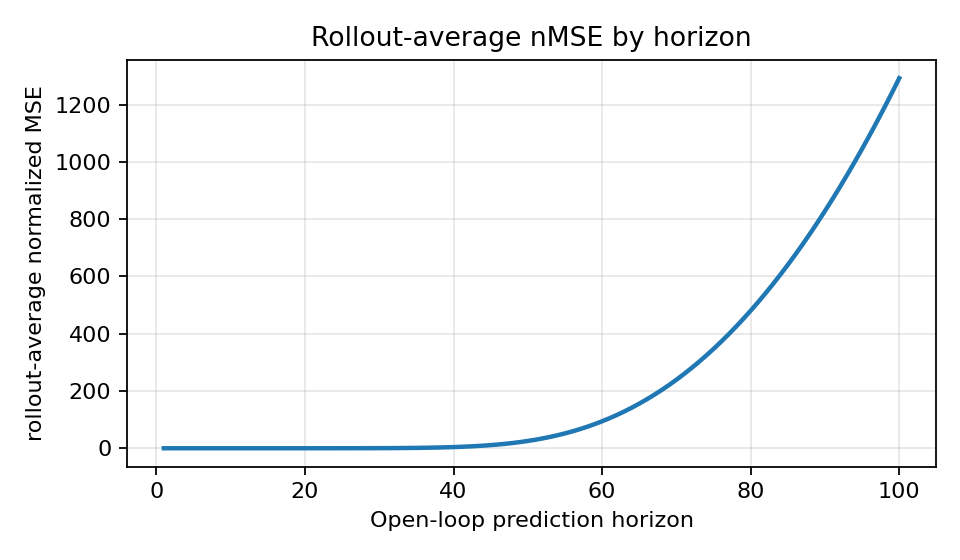

In [ ]:
!{sys.executable} -m wm_hw.plotting --eval-dir artifacts/student/eval_test --output-dir artifacts/student/plots

import json
from IPython.display import Image, display

with open("artifacts/student/eval_test/metrics.json", "r", encoding="utf-8") as f:
    test_metrics = json.load(f)
with open("artifacts/student/eval_ood/metrics.json", "r", encoding="utf-8") as f:
    ood_metrics = json.load(f)

print("test VPT80@0.25:", test_metrics["VPT80@0.25"])
print("ood VPT80@0.25:", ood_metrics["VPT80@0.25"])
print("test max_horizon:", test_metrics["max_horizon"])
print("test nMSE_AUC:", test_metrics["nMSE_AUC"])
display(Image("artifacts/student/plots/survival_curve.png"))
display(Image("artifacts/student/plots/rollout_comparison.png"))

## 8. Optional Long-Horizon Scoreboard

The regular cells above stay lightweight. If you want the final public scoreboard artifacts, set `RUN_SCOREBOARD_DEMO = True` and `SMOKE_RUN = False` in the first cell. The public scoreboard config uses `warmup_steps=10` and `max_horizon=1000`.

In [ ]:
if RUN_SCOREBOARD_DEMO:
    import json
    assert not SMOKE_RUN, "Final scoreboard artifacts require SMOKE_RUN = False."
    SCOREBOARD_DIR = "data/public_scoreboard"
    run([sys.executable, "-m", "wm_hw.dataset", "--config", "configs/public_scoreboard.yaml", "--output-dir", SCOREBOARD_DIR])
    run([sys.executable, "-m", "wm_hw.eval_horizon", "--checkpoint-dir", "artifacts/student/best_checkpoint", "--dataset-dir", SCOREBOARD_DIR, "--split", "test", "--horizon", "auto", "--eval-config", "configs/official_eval.yaml", "--output-dir", "artifacts/student/public_scoreboard_test"])
    run([sys.executable, "-m", "wm_hw.plotting", "--eval-dir", "artifacts/student/public_scoreboard_test", "--output-dir", "artifacts/student/public_scoreboard_plots"])
    run(["bash", "-lc", "cd artifacts/student && zip -qr final_artifacts.zip best_checkpoint eval_test eval_ood plots public_scoreboard_test public_scoreboard_plots"])
    with open("artifacts/student/public_scoreboard_test/scoreboard_summary.json", "r", encoding="utf-8") as f:
        print(json.load(f))
else:
    print("Set RUN_SCOREBOARD_DEMO = True in the first cell to run the long-horizon scoreboard demo.")